# 06 — Topic Modeling × Familles politiques

**Question** : comment les familles politiques se distribuent dans l'espace
thématique, et comment cette distribution évolue de 1973 à 1993 ?

Pipeline :
1. **LDA global** (toutes périodes confondues) avec K topics
2. **Mapping** des partis individuels (`titulaire-soutien`) en familles politiques
3. **Distribution thématique** par famille × année (Thematic propensity)
4. **Indice de spécialisation** (lift = P(t|fam) / P(t)) → où chaque famille est sur-représentée
5. **Carte sémantique 2D** : projection PCA des familles dans l'espace topic
6. **Trajectoires diachroniques** : évolution de chaque famille

5. **Carte sémantique 2D** : projection PCA des familles dans l'espace topic
6. **Trajectoires diachroniques** : évolution de chaque famille
7. **Profession × topics / Âge × topics** : moyenne de $\theta$ et lift (section 6bis)


**Note méthodologique** : LDA global pour avoir des topics comparables
entre années (sinon problème d'alignement type Procrustes mais sur les topics).
Les variations dans le temps se mesurent par les distributions de documents,
pas par des topics qui changeraient.

## 1. Setup — corpus + métadonnées + filtrage OCR (allemand)

In [22]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
from gensim import corpora
from gensim.models import LdaMulticore, CoherenceModel
from sklearn.decomposition import PCA

sns.set_theme(style='whitegrid')
Path('../results/figures').mkdir(exist_ok=True)
Path('../results/models').mkdir(exist_ok=True)
Path('../results/tables').mkdir(exist_ok=True)

YEARS = [1973, 1978, 1981, 1988, 1993]

# Mots allemands fréquents (Alsace-Moselle, traductions officielles passées au filet)
GERMAN_STOPWORDS = {
    'eine','einen','einer','eines','werden','wird','wurde','durch','sich','sind',
    'haben','partei','damit','unter','gegen','müssen','muss','kann','können','soll',
    'sollen','wollen','ihre','ihrer','unsere','aller','alle','mehr','auch','aber',
    'wenn','denn','doch','noch','nicht','sein','jeden','jeder','jede','zwischen',
    'oder','sondern','dass','dieser','diese','dieses','mein','von','zur','zum',
    'der','die','das','den','des','dem','und','ist','war','wäre','wird','sind',
}

# Charger les corpus bigrammés + filtrer les mots allemands
corpus_by_year = {}
for y in YEARS:
    with open(f'../data/processed/corpus_bigrams_{y}.pkl', 'rb') as f:
        raw = pickle.load(f)
    cleaned = [[t for t in doc if t.lower() not in GERMAN_STOPWORDS] for doc in raw]
    corpus_by_year[y] = cleaned
    print(f'{y}: {len(cleaned)} docs')

# Charger les document_ids dans l'ordre EXACT des corpus tokenisés
# (généré par notebook 02 — si manquant, message explicatif)
doc_ids_by_year = {}
missing = []
for y in YEARS:
    p = Path(f'../data/processed/doc_ids_{y}.pkl')
    if p.exists():
        with open(p, 'rb') as f:
            doc_ids_by_year[y] = pickle.load(f)
    else:
        missing.append(y)

if missing:
    raise FileNotFoundError(
        f'Fichiers doc_ids manquants pour {missing}. '
        'Re-runne la cellule 4 du notebook 02 (mise à jour pour sauvegarder les doc_ids).'
    )

df_full = pd.read_csv('../data/metadata/corpus_complet.csv')

# Sanity check
for y in YEARS:
    n_corp = len(corpus_by_year[y])
    n_ids  = len(doc_ids_by_year[y])
    status = '✓' if n_corp == n_ids else '✗ DÉCALAGE'
    print(f'  {y}: corpus={n_corp} docs / doc_ids={n_ids}  {status}')

1973: 3917 docs
1978: 5025 docs
1981: 3179 docs
1988: 3615 docs
1993: 5929 docs
  1973: corpus=3917 docs / doc_ids=3917  ✓
  1978: corpus=5025 docs / doc_ids=5025  ✓
  1981: corpus=3179 docs / doc_ids=3179  ✓
  1988: corpus=3615 docs / doc_ids=3615  ✓
  1993: corpus=5929 docs / doc_ids=5929  ✓


## 2. Mapping partis → familles politiques

On regroupe les ~30 valeurs de `titulaire-soutien` en 5 familles cohérentes
à travers les périodes pour permettre la comparaison diachronique.

In [23]:
meta = pd.read_csv('../data/metadata/archelec.csv', low_memory=False)
meta = meta[['id', 'titulaire-soutien', 'titulaire-liste',
             'titulaire-profession', 'titulaire-sexe',
             'titulaire-age-tranche', 'departement-insee']]
meta = meta.rename(columns={'titulaire-soutien': 'soutien',
                            'titulaire-liste': 'liste',
                            'titulaire-profession': 'profession',
                            'titulaire-sexe': 'sexe',
                            'titulaire-age-tranche': 'age_tranche'})


def famille_politique(soutien):
    """Mapping de `titulaire-soutien` vers 6 familles politiques cohérentes 1973-1993.

    Ordre critique : on traite les cas exclusifs (FN, écolo) d'abord, puis les
    alliances droite (où on privilégie le RPR sur l'UDF en cas de double mention).
    """
    if pd.isna(soutien) or soutien == 'non mentionné':
        return 'autres'
    s = str(soutien).lower()

    if 'front national' in s:
        return 'extreme_droite'

    if any(k in s for k in ['écolog', 'verts', 'génération écologie',
                             'rassemblement nature']):
        return 'ecologistes'

    # Gauche radicale : PCF, LO, LCR, PSU, FGDS
    if any(k in s for k in ['parti communiste français', 'lutte ouvrière',
                             'communiste révolutionnaire', 'parti socialiste unifié',
                             'fédération de la gauche démocrate']):
        return 'gauche_radicale'

    # Gauche modérée : PS, MRG, SFIO
    if 'parti socialiste' in s or 'radicaux de gauche' in s or 'sfio' in s:
        return 'gauche'

    # Droite gaulliste : RPR, UNR, UDR, alliances "RPR;UDF" ou "UDF;RPR"
    if any(k in s for k in ['rassemblement pour la république', 'rpr',
                             'défense de la république', 'udr', 'union gaulliste']):
        return 'droite_gaulliste'

    # Centre-droit : UDF, Centre démocrate, MRP, URP
    if any(k in s for k in ['union pour la démocratie', 'centre démocrate',
                             'mouvement républicain', 'républicains de progrès',
                             'démocrate']):
        return 'centre_droite'

    return 'autres'


meta['famille'] = meta['soutien'].apply(famille_politique)

df_meta = df_full.merge(meta, left_on='document_id', right_on='id', how='left')
df_meta['famille'] = df_meta['famille'].fillna('autres')

print('Distribution des familles politiques par année :')
print(pd.crosstab(df_meta['year'], df_meta['famille']))
print(f'\nDocs avec famille politique attribuée (hors autres) : '
      f'{(df_meta["famille"] != "autres").sum():,} / {len(df_meta):,}')

Distribution des familles politiques par année :
famille  autres  centre_droite  droite_gaulliste  ecologistes  extreme_droite  \
year                                                                            
1973       1348            886                 0            0             102   
1978       1635            431               548           73             135   
1981        991            148               389           48              45   
1988       1697             57               532           21             546   
1993       1945            147               871         1138             651   

famille  gauche  gauche_radicale  
year                              
1973        534             1051  
1978        723             1485  
1981        680              881  
1988        232              543  
1993        338              846  

Docs avec famille politique attribuée (hors autres) : 14,081 / 21,697


## 3. Dictionnaire + LDA global

In [24]:
all_docs = [doc for y in YEARS for doc in corpus_by_year[y]]

dictionary = corpora.Dictionary(all_docs)
dictionary.filter_extremes(no_below=10, no_above=0.7)
print(f'Dictionnaire : {len(dictionary):,} tokens')

bow_all = [dictionary.doc2bow(doc) for doc in all_docs]

Dictionnaire : 12,022 tokens


  K= 8  C_v=0.4116
  K=10  C_v=0.4414
  K=12  C_v=0.4942
  K=15  C_v=0.4616
  K=20  C_v=0.4423

→ K optimal : 12


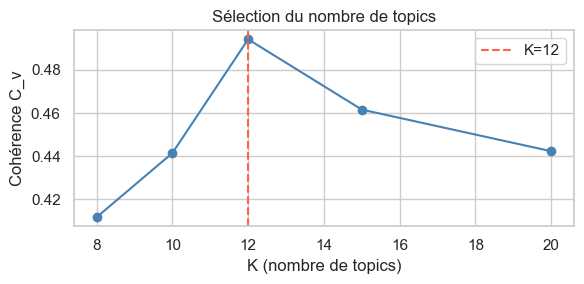

In [25]:
# Sélection K via cohérence C_v
K_RANGE = [8, 10, 12, 15, 20]
coherences = []
for k in K_RANGE:
    lda = LdaMulticore(corpus=bow_all, id2word=dictionary, num_topics=k,
                       workers=3, passes=10, random_state=42)
    cm = CoherenceModel(model=lda, texts=all_docs,
                        dictionary=dictionary, coherence='c_v')
    coh = cm.get_coherence()
    coherences.append(coh)
    print(f'  K={k:2d}  C_v={coh:.4f}')

K = K_RANGE[np.argmax(coherences)]
print(f'\n→ K optimal : {K}')

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(K_RANGE, coherences, marker='o', color='steelblue')
ax.axvline(K, color='tomato', linestyle='--', label=f'K={K}')
ax.set_xlabel('K (nombre de topics)')
ax.set_ylabel('Cohérence C_v')
ax.set_title('Sélection du nombre de topics')
ax.legend()
plt.tight_layout()
plt.savefig('../results/figures/06_coherence_k.png', dpi=150)
plt.show()

In [26]:
# Entraînement final
lda = LdaMulticore(corpus=bow_all, id2word=dictionary, num_topics=K,
                   workers=3, passes=30, random_state=42, alpha='symmetric')
lda.save('../results/models/lda_global.model')

print('Topics globaux (top 10 mots) :')
for tid, words in lda.show_topics(num_topics=K, num_words=10, formatted=False):
    top = ', '.join(w for w, _ in words)
    print(f'  T{tid:02d}: {top}')

Topics globaux (top 10 mots) :
  T00: social, entreprise, liberté, programme, france, retraite, économique, travail, droit, emploi
  T01: national, front, force, député, avenir, france, contre, populaire, voter, suppression
  T02: entreprise, travailleur, payer, patron, maintenir, emploi, patronat, vendre, chômage, année
  T03: france, majorité, député, socialiste, confiance, union, maire, national, président, progrès
  T04: maire, conseiller, général, enfant, union, président, député, municipal, socialiste, national
  T05: national, immigration, france, impôt, nature, contre, votez, immigré, nouveau, chômage
  T06: travailleur, contre, droit, société, socialisme, lutte, ouvrier, gauche, travail, populaire
  T07: communiste, gauche, parti, droite, voter, programme, changement, commun, union, gouvernement
  T08: écologie, emploi, environnement, écologiste, nouveau, homme, pays, monde, solidarité, développement
  T09: travailleur, lutte, voter, ouvrier, progrès, gauche, gouvernement, rév

## 4. Labels manuels des topics

À partir des top-mots, on attribue un label interprétable à chaque topic.
**À ajuster manuellement** après inspection des sorties précédentes.

In [ ]:
TOPIC_LABELS_DEFAULT = {i: f'T{i}' for i in range(K)}


TOPIC_LABELS = TOPIC_LABELS_DEFAULT.copy()


# Affichage avec les top-3 mots 
for tid in range(K):
    if TOPIC_LABELS[tid] == f'T{tid}':
        top3 = ', '.join(w for w, _ in lda.show_topic(tid, topn=3))
        TOPIC_LABELS[tid] = f'T{tid}: {top3}'

print('Labels des topics :')
for tid, lbl in TOPIC_LABELS.items():
    print(f'  {lbl}')

Labels des topics :
  T0: social, entreprise, liberté
  T1: national, front, force
  T2: entreprise, travailleur, payer
  T3: france, majorité, député
  T4: maire, conseiller, général
  T5: national, immigration, france
  T6: travailleur, contre, droit
  T7: communiste, gauche, parti
  T8: écologie, emploi, environnement
  T9: travailleur, lutte, voter
  T10: alsace, région, strasbourg
  T11: travailleur, voter, gauche


## 5. Distribution thématique par document

Pour chaque document, on calcule sa distribution θ sur les K topics.
On indexe ces vecteurs par `document_id` pour pouvoir les croiser avec
les métadonnées (famille politique, profession, département).

In [28]:
# Mapping exact : ordered_doc_ids[i] correspond à all_docs[i] et bow_all[i]
ordered_doc_ids = [doc_id for y in YEARS for doc_id in doc_ids_by_year[y]]
assert len(ordered_doc_ids) == len(bow_all), \
    f'Décalage corpus/doc_ids : {len(ordered_doc_ids)} vs {len(bow_all)}'

theta_matrix = np.zeros((len(bow_all), K))
for i, bow in enumerate(bow_all):
    for t, p in lda.get_document_topics(bow, minimum_probability=0):
        theta_matrix[i, t] = p

theta_df = pd.DataFrame(theta_matrix,
                         columns=[TOPIC_LABELS[t] for t in range(K)],
                         index=ordered_doc_ids)
theta_df.index.name = 'document_id'

theta_meta = theta_df.merge(
    df_meta[['document_id', 'year', 'famille', 'profession', 'sexe',
             'age_tranche', 'departement-insee']],
    left_index=True, right_on='document_id', how='left'
)

print(f'Matrice θ : {theta_df.shape}')
print(f'  Documents avec famille politique connue (≠ autres) : '
      f'{(theta_meta["famille"] != "autres").sum():,}')
theta_meta.head(3)

Matrice θ : (21665, 12)
  Documents avec famille politique connue (≠ autres) : 14,079


,"T0: social, entreprise, liberté","T1: national, front, force","T2: entreprise, travailleur, payer","T3: france, majorité, député","T4: maire, conseiller, général","T5: national, immigration, france","T6: travailleur, contre, droit","T7: communiste, gauche, parti","T8: écologie, emploi, environnement","T9: travailleur, lutte, voter","T10: alsace, région, strasbourg","T11: travailleur, voter, gauche",document_id,year,famille,profession,sexe,age_tranche,departement-insee
0,0.490554,0.065409,0.000275,0.121640,0.000275,0.000274,0.265225,0.000275,0.000275,0.055251,0.000274,0.000275,EL067_L_1973_03_059_10_1_PF_04,1973,autres,non mentionné,homme,non mentionné,59 - Nord
1,0.330684,0.000390,0.000390,0.297469,0.368337,0.000390,0.000390,0.000390,0.000390,0.000390,0.000390,0.000390,EL066_L_1973_03_044_05_1_PF_03,1973,autres,non mentionné,homme,non mentionné,44 - Loire-Atlantique
2,0.031240,0.000425,0.010664,0.919756,0.000425,0.034937,0.000425,0.000425,0.000425,0.000425,0.000425,0.000425,EL069_L_1973_03_080_02_1_PF_04,1973,autres,cadre juridique,homme,non mentionné,80 - Somme


## 6. Distribution thématique par famille politique × année

*Thematic propensity*. On calcule, pour chaque cellule (famille, année),
la moyenne des distributions θ de ses documents.
C'est le profil thématique de cette famille à cette élection.

Effectifs par cellule (n_docs) :
famille  centre_droite  droite_gaulliste  ecologistes  extreme_droite  gauche  \
year                                                                            
1973               886                 0            0             102     534   
1978               431               547           73             134     723   
1981               148               389           48              45     680   
1988                57               532           21             546     232   
1993               147               871         1138             651     338   

famille  gauche_radicale  
year                      
1973                1051  
1978                1485  
1981                 881  
1988                 543  
1993                 846  


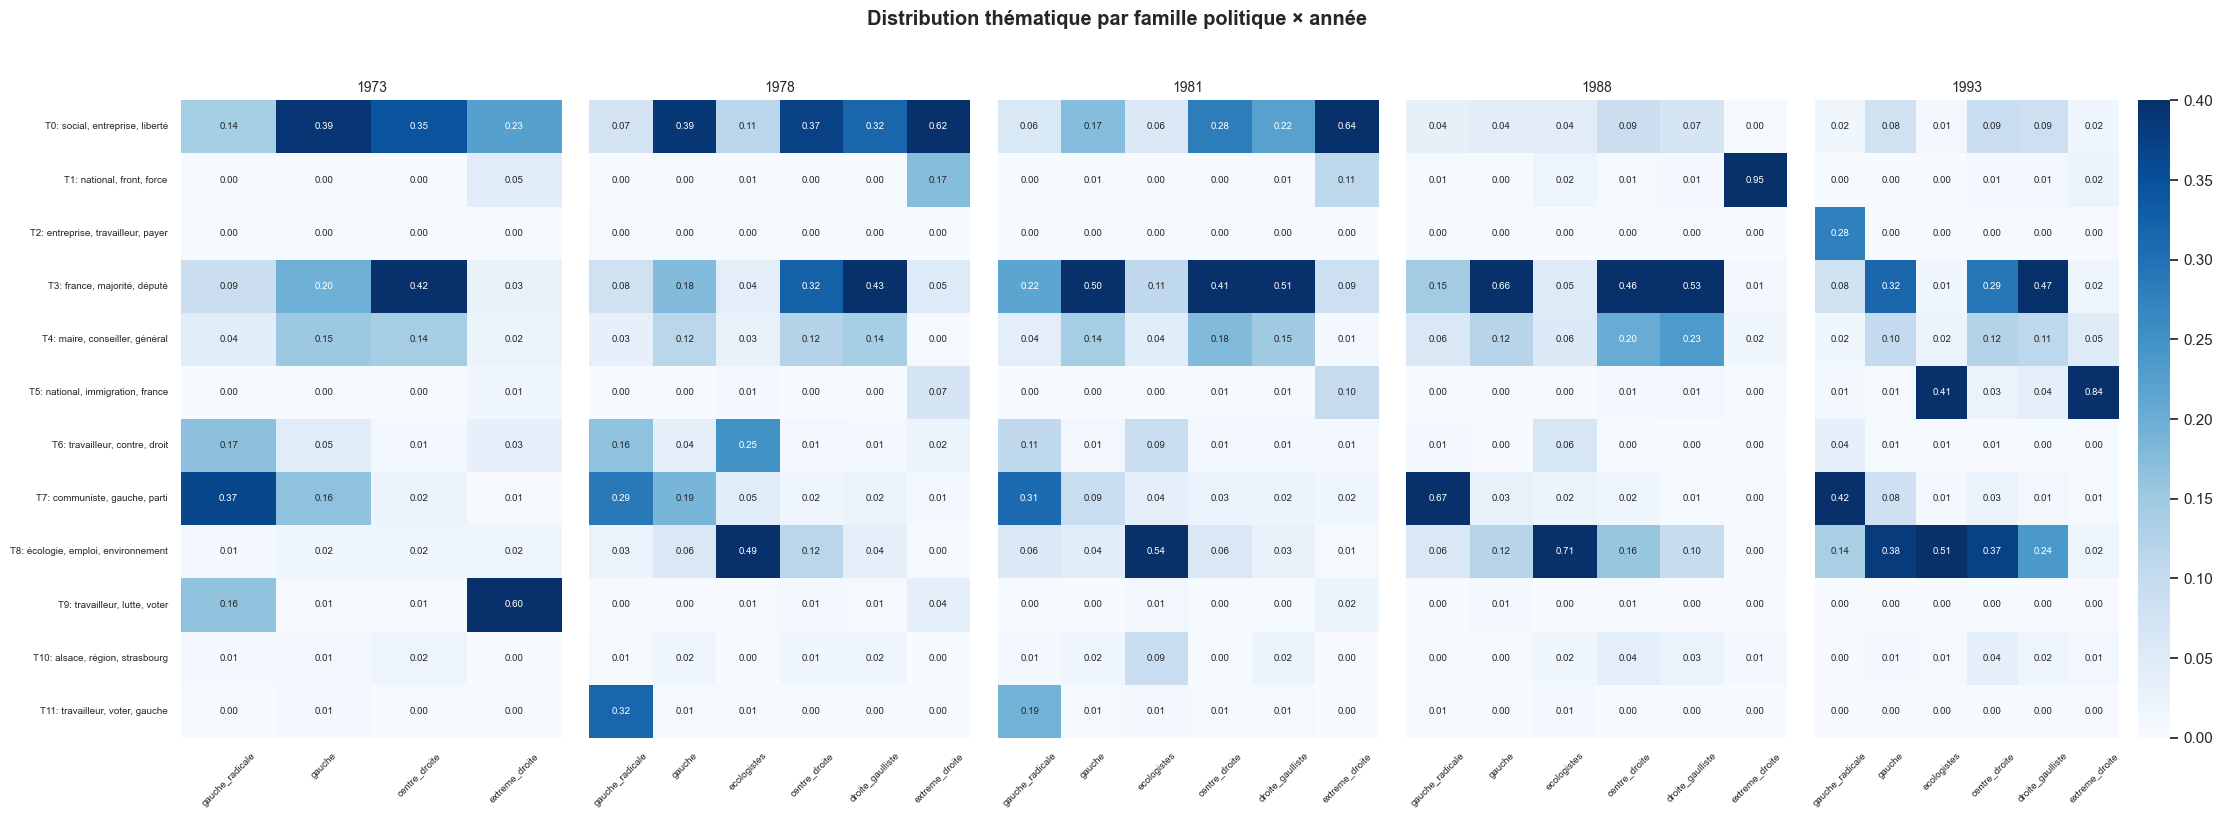

In [29]:
FAMILLES = ['gauche_radicale', 'gauche', 'ecologistes', 'centre_droite',
            'droite_gaulliste', 'extreme_droite']

# Filtrer les familles connues uniquement
tm = theta_meta[theta_meta['famille'].isin(FAMILLES)].copy()

topic_cols = [TOPIC_LABELS[t] for t in range(K)]

# Profil thématique moyen par (année, famille)
profil = tm.groupby(['year', 'famille'])[topic_cols].mean()
n_docs = tm.groupby(['year', 'famille']).size().rename('n_docs')

print('Effectifs par cellule (n_docs) :')
print(n_docs.unstack(fill_value=0))

# Heatmap par année
fig, axes = plt.subplots(1, len(YEARS), figsize=(4.5 * len(YEARS), 0.5 * K + 2),
                          sharey=True)
for ax, y in zip(axes, YEARS):
    if y not in profil.index.get_level_values('year'):
        ax.set_title(str(y))
        continue
    sub = profil.xs(y, level='year')
    fam_present = [f for f in FAMILLES if f in sub.index]
    sub = sub.loc[fam_present]

    sns.heatmap(sub.T, ax=ax, cmap='Blues', vmin=0, vmax=0.4,
                cbar=(ax == axes[-1]), annot=True, fmt='.2f',
                annot_kws={'size': 7})
    ax.set_title(str(y), fontsize=10)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.tick_params(axis='y', rotation=0, labelsize=7)

plt.suptitle('Distribution thématique par famille politique × année',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../results/figures/06_propensity_by_party.png', dpi=150,
            bbox_inches='tight')
plt.show()

profil.to_csv('../results/tables/06_propensity_par_famille.csv')

## 6bis. Topics × professions et × tranches d'âge

*Cross-metadata* : même matrice \(\theta\) que ci-dessus, mais agrégée sur des métadonnées **profession / âge** plutôt que sur la famille politique.

Pour les professions (`titulaire-profession`), on regroupe automatiquement par mots-clés (ordre de priorité), afin d'éviter les milliers de modalités quasi uniques.

On calcule la moyenne de \(\theta\) par groupe ainsi qu'un **lift** par rapport au profil global *toutes professions confondues* (\(P(t \mid groupe) / P(t)\)).

**Limite.** Fort confondement avec le **parti** (ex. agriculteurs déclarés sur des courants ruraux de droite). Ces graphiques se lisent comme des *associations observées* dans les professions de foi ; ils ne constituent pas une preuve d'effet propre au métier.


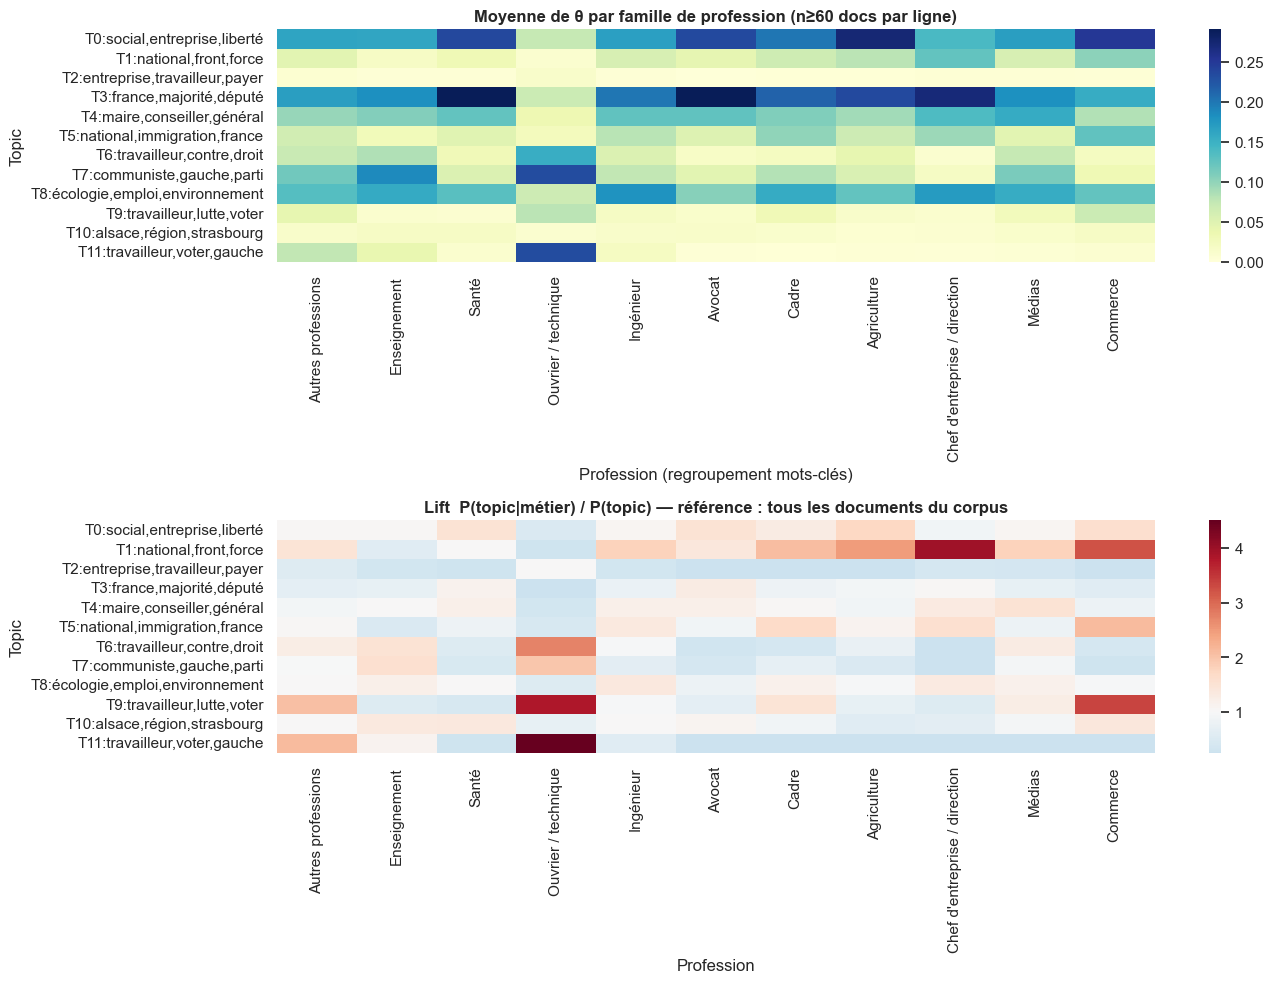

Profession : groupes retenus (n≥60) → ['Autres professions', 'Enseignement', 'Santé', 'Ouvrier / technique', 'Ingénieur', 'Avocat', 'Cadre', 'Agriculture', "Chef d'entreprise / direction", 'Médias', 'Commerce']

Top 15 paires métier-topic (lift) :
profession_grp                                                  
Ouvrier / technique            T11: travailleur, voter, gauche      6.531
Chef d'entreprise / direction  T1: national, front, force           3.963
Ouvrier / technique            T9: travailleur, lutte, voter        3.809
Commerce                       T9: travailleur, lutte, voter        3.358
                               T1: national, front, force           3.230
Ouvrier / technique            T6: travailleur, contre, droit       2.735
Agriculture                    T1: national, front, force           2.497
Commerce                       T5: national, immigration, france    2.117
Autres professions             T11: travailleur, voter, gauche      2.115
Cadre                

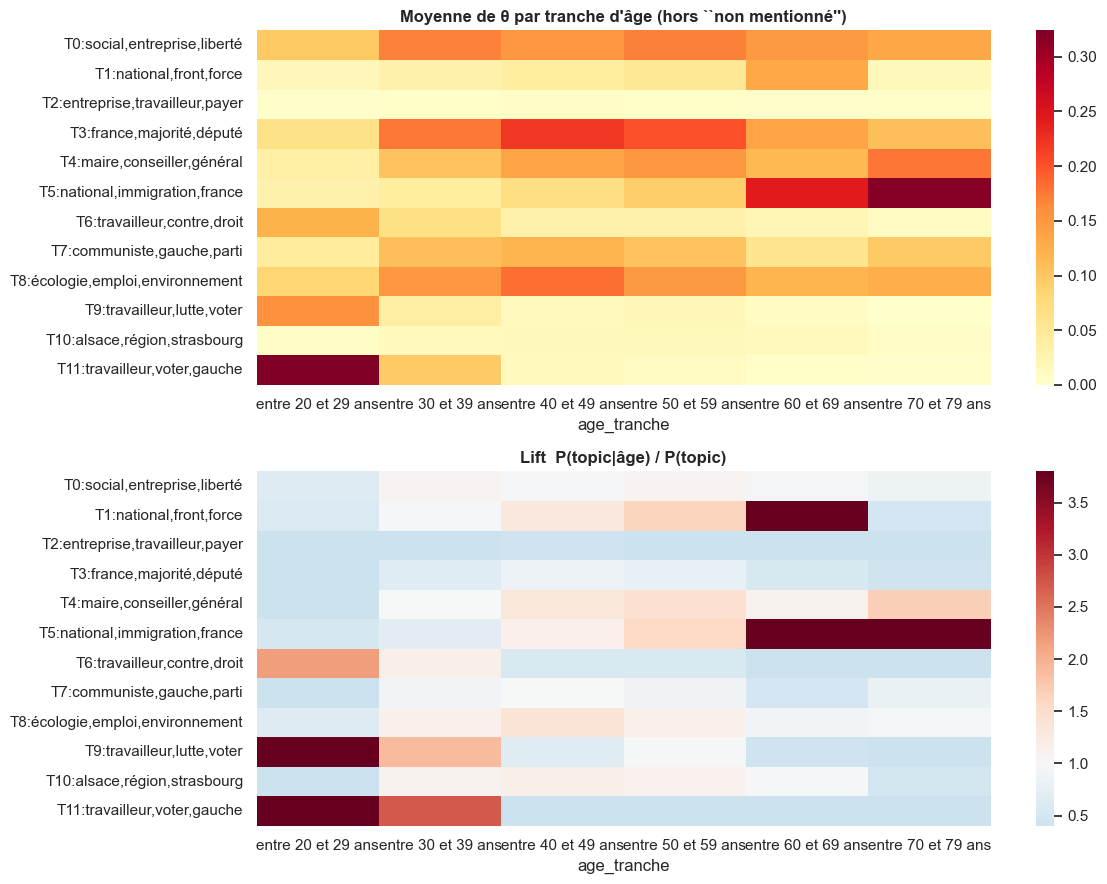


Âge : effectifs par tranche (docs conservés) :
age_tranche
entre 20 et 29 ans    1058
entre 30 et 39 ans    2589
entre 40 et 49 ans    2742
entre 50 et 59 ans    1266
entre 60 et 69 ans     264
entre 70 et 79 ans      16
Name: count, dtype: int64


In [30]:



import numpy as np

def categorize_profession(p):
    """Regroupe quelques familles métier lisibles (~10 cat.). Ordre prioritaire."""
    if pd.isna(p):
        return np.nan
    s = str(p).strip().lower()
    if s in ('', 'nan', 'non mentionné'):
        return np.nan
    if any(k in s for k in [
        'agriculteur', 'agricole', 'viticulteur', 'exploit', 'paysan',
        'viticole',
    ]):
        return 'Agriculture'
    if any(k in s for k in ['professeur', 'instituteur', 'enseignant', 'éducateur', 'principal']):
        return 'Enseignement'
    if any(k in s for k in [
        'docteur', 'médecin', 'dentiste', 'vétérinaire', 'infirmier',
        'pharmacien', 'chirurgien',
    ]) or 'medecine' in s.replace('é', 'e'):
        return 'Santé'
    if 'avocat' in s:
        return 'Avocat'
    if 'ingénieur' in s:
        return 'Ingénieur'
    if any(k in s for k in ['journaliste', 'rédacteur']):
        return 'Médias'
    if any(k in s for k in ['commerçant', 'boutique']):
        return 'Commerce'
    if any(k in s for k in ["chef d'entreprise", 'dirigeant', 'directeur général']):
        return "Chef d'entreprise / direction"
    if any(k in s for k in ['ouvrier', 'technicien', 'cheminot']):
        return 'Ouvrier / technique'
    if 'cadre' in s:
        return 'Cadre'
    return 'Autres professions'

# Étiquettes courtes pour heatmaps
_SHORT = []
for t in range(K):
    lbl = TOPIC_LABELS[t]
    tail = lbl.split(': ', 1)[-1] if ': ' in lbl else lbl
    words = [w.strip(',') for w in tail.split()]
    suf = ','.join(words[:3])
    _SHORT.append(f'T{t}:{suf}')
_rename = dict(zip(topic_cols, _SHORT))

META_T = theta_meta.copy()

# ── Profession ──────────────────────────────────────────
META_T['profession_grp'] = META_T['profession'].apply(categorize_profession)

MIN_DOCS = 60
_vc = META_T['profession_grp'].value_counts(dropna=True)
PROF_ROWS = [g for g in _vc.index if _vc[g] >= MIN_DOCS]
META_P = META_T[META_T['profession_grp'].isin(PROF_ROWS)]

prof_theta = META_P.groupby('profession_grp', observed=False)[topic_cols].mean()
prof_theta = prof_theta.loc[sorted(PROF_ROWS, key=lambda x: -_vc[x])]

glob_all = META_T[topic_cols].mean()
lift_prof = prof_theta.div(glob_all + 1e-12)

fig, axes = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [1.0, 1.0]})
v_top = np.quantile(prof_theta.values, 0.99)
sns.heatmap(
    prof_theta.rename(columns=_rename).T,
    ax=axes[0], cmap='YlGnBu', vmin=0, vmax=float(v_top),
)
axes[0].set_title(
    f"Moyenne de θ par famille de profession (n≥{MIN_DOCS} docs par ligne)",
    fontweight='bold',
)
axes[0].set_xlabel('Profession (regroupement mots-clés)')
axes[0].set_ylabel('Topic')

vmin_l = float(np.maximum(0.25, lift_prof.values.min()))
vmax_l = float(np.minimum(4.5, lift_prof.values.max()))
sns.heatmap(
    lift_prof.rename(columns=_rename).T,
    ax=axes[1], cmap='RdBu_r', center=1.0, vmin=vmin_l, vmax=vmax_l,
)
axes[1].set_title(
    'Lift  P(topic|métier) / P(topic) — référence : tous les documents du corpus',
    fontweight='bold',
)
axes[1].set_xlabel('Profession')
axes[1].set_ylabel('Topic')

plt.tight_layout()
plt.savefig('../results/figures/06_topics_par_profession.png', dpi=150, bbox_inches='tight')
plt.show()

prof_theta.to_csv('../results/tables/06_topics_par_profession.csv')
lift_prof.to_csv('../results/tables/06_lift_profession_topics.csv')

print(f'Profession : groupes retenus (n≥{MIN_DOCS}) → {list(prof_theta.index)}')
print('\nTop 15 paires métier-topic (lift) :')
print(lift_prof.stack().sort_values(ascending=False).head(15).round(3).to_string())

# ── Tranche d'âge ─────────────────────────────────────────
_age_order = [
    'entre 20 et 29 ans',
    'entre 30 et 39 ans',
    'entre 40 et 49 ans',
    'entre 50 et 59 ans',
    'entre 60 et 69 ans',
    'entre 70 et 79 ans',
    'entre 80 et 89 ans',
]
META_A = theta_meta[theta_meta['age_tranche'].astype(str).str.strip() != 'non mentionné'].copy()
META_A['_age_ord'] = pd.Categorical(META_A['age_tranche'], categories=_age_order, ordered=True)
META_A = META_A.sort_values('_age_ord')
age_theta = META_A.groupby('age_tranche', observed=True)[topic_cols].mean()
age_theta = age_theta.reindex([a for a in _age_order if a in age_theta.index])

glob_age_ref = META_T[topic_cols].mean()
lift_age = age_theta.div(glob_age_ref + 1e-12)

fig2, axes2 = plt.subplots(2, 1, figsize=(12, 9))
vat = np.quantile(np.nan_to_num(age_theta.values, nan=0.0), 0.99)
sns.heatmap(
    age_theta.rename(columns=_rename).T,
    ax=axes2[0], cmap='YlOrRd', vmin=0, vmax=float(vat),
)
axes2[0].set_title("Moyenne de θ par tranche d'âge (hors ``non mentionné'')", fontweight='bold')

v2_min = float(np.maximum(0.4, lift_age.values.min()))
v2_max = float(np.minimum(3.8, lift_age.values.max()))
sns.heatmap(
    lift_age.rename(columns=_rename).T,
    ax=axes2[1], cmap='RdBu_r', center=1.0, vmin=v2_min, vmax=v2_max,
)
axes2[1].set_title('Lift  P(topic|âge) / P(topic)',
                   fontweight='bold')

plt.tight_layout()
plt.savefig('../results/figures/06_topics_par_age_tranche.png', dpi=150, bbox_inches='tight')
plt.show()

age_theta.to_csv('../results/tables/06_topics_par_age_tranche.csv')
lift_age.to_csv('../results/tables/06_lift_age_topics.csv')

print("\nÂge : effectifs par tranche (docs conservés) :")
print(META_A['age_tranche'].value_counts().sort_index())


## 7. Indice de spécialisation thématique (lift)

$$\text{lift}(\text{topic}, \text{famille}) = \frac{P(\text{topic} \mid \text{famille})}{P(\text{topic})}$$

- lift > 1 : la famille est sur-représentée sur ce topic
- lift < 1 : sous-représentée
- lift ~ 1 : neutre

On calcule cela par année.

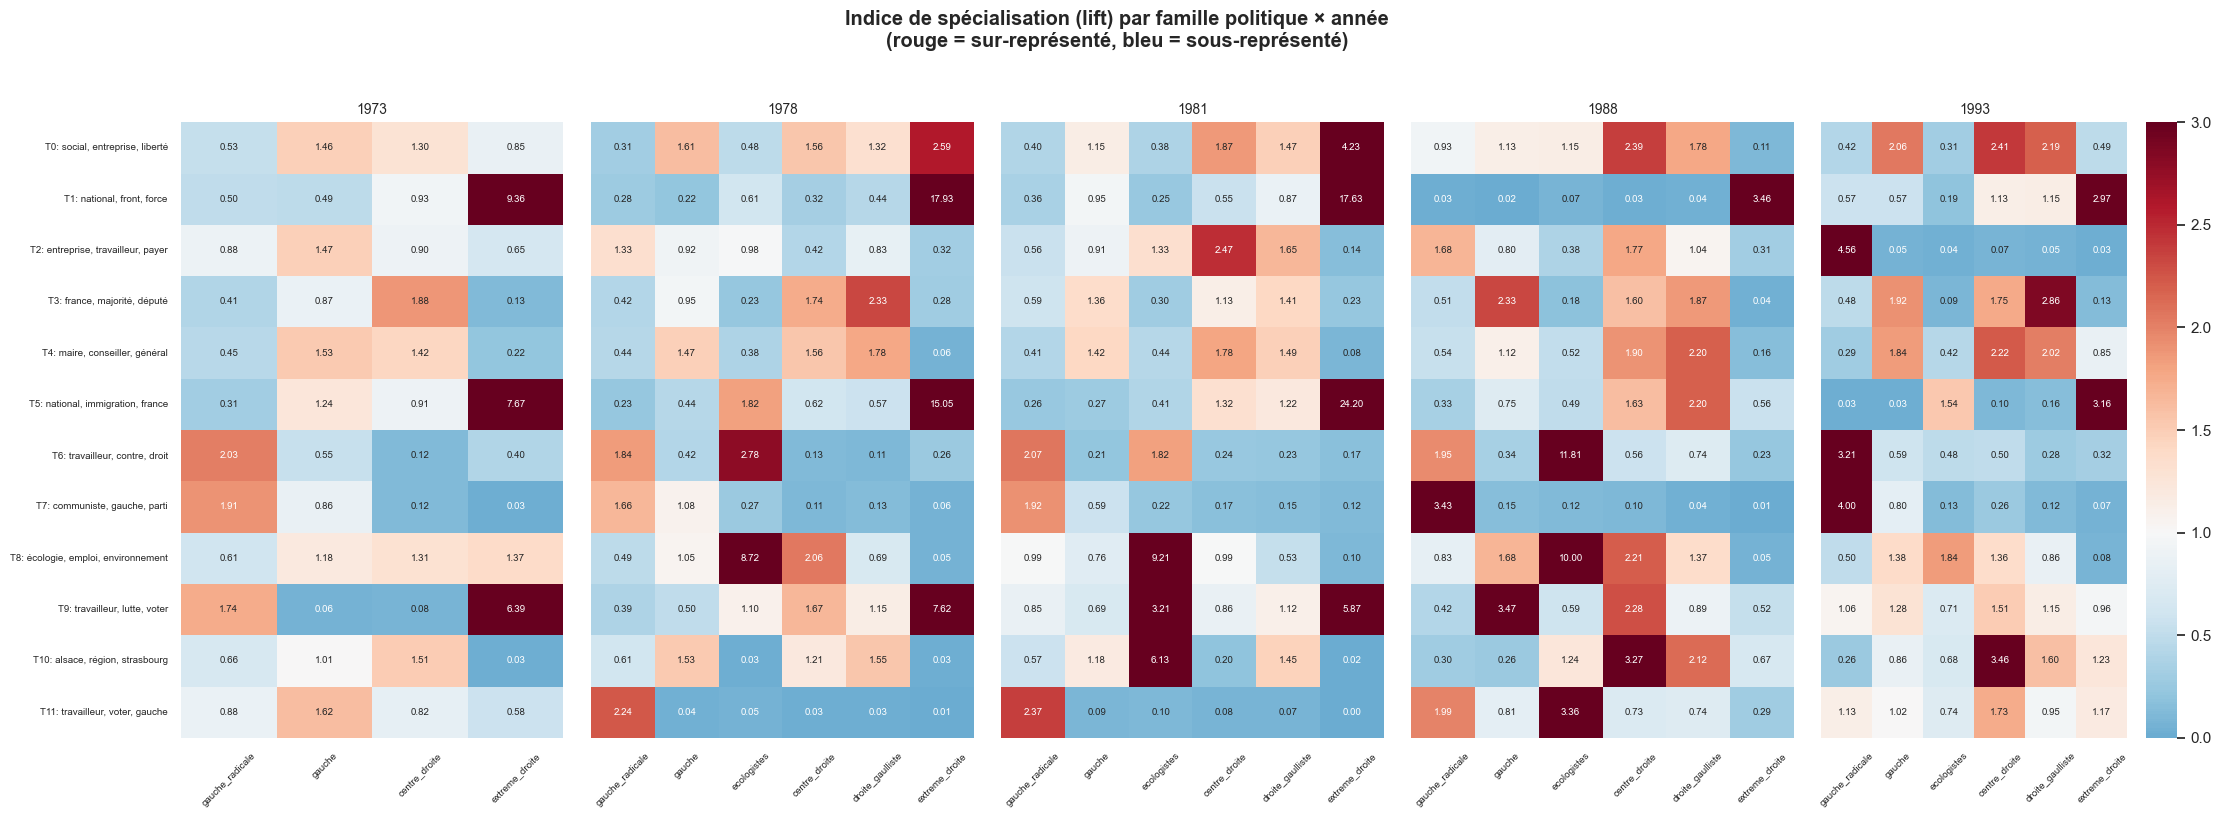


Top 20 sur-représentations (famille × topic × année) :
 year         famille                               topic      lift
 1981  extreme_droite   T5: national, immigration, france 24.199529
 1978  extreme_droite          T1: national, front, force 17.933614
 1981  extreme_droite          T1: national, front, force 17.633349
 1978  extreme_droite   T5: national, immigration, france 15.049757
 1988     ecologistes      T6: travailleur, contre, droit 11.807361
 1988     ecologistes T8: écologie, emploi, environnement 10.001983
 1973  extreme_droite          T1: national, front, force  9.358445
 1981     ecologistes T8: écologie, emploi, environnement  9.212887
 1978     ecologistes T8: écologie, emploi, environnement  8.724241
 1973  extreme_droite   T5: national, immigration, france  7.671299
 1978  extreme_droite       T9: travailleur, lutte, voter  7.622389
 1973  extreme_droite       T9: travailleur, lutte, voter  6.386646
 1981     ecologistes     T10: alsace, région, strasbourg  6

In [31]:
# Distribution moyenne globale par année (référence)
global_dist_by_year = tm.groupby('year')[topic_cols].mean()

# Lift = P(topic | famille, année) / P(topic | année)  — vectorisé via broadcast
lift = profil.div(global_dist_by_year + 1e-9, level='year').fillna(0)

# Heatmap lift par année
fig, axes = plt.subplots(1, len(YEARS), figsize=(4.5 * len(YEARS), 0.5 * K + 2),
                          sharey=True)
for ax, y in zip(axes, YEARS):
    if y not in lift.index.get_level_values('year'):
        continue
    sub = lift.xs(y, level='year')
    fam_present = [f for f in FAMILLES if f in sub.index]
    sub = sub.loc[fam_present]
    sns.heatmap(sub.T, ax=ax, cmap='RdBu_r', center=1.0, vmin=0, vmax=3,
                cbar=(ax == axes[-1]), annot=True, fmt='.2f',
                annot_kws={'size': 7})
    ax.set_title(str(y), fontsize=10)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.tick_params(axis='y', rotation=0, labelsize=7)

plt.suptitle('Indice de spécialisation (lift) par famille politique × année\n'
             '(rouge = sur-représenté, bleu = sous-représenté)',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../results/figures/06_specialisation_lift.png', dpi=150,
            bbox_inches='tight')
plt.show()

lift.to_csv('../results/tables/06_lift_par_famille.csv')

# Top spécialisations
lift_long = lift.stack().reset_index()
lift_long.columns = ['year', 'famille', 'topic', 'lift']
print('\nTop 20 sur-représentations (famille × topic × année) :')
print(lift_long.nlargest(20, 'lift').to_string(index=False))

## 8. Carte sémantique 2D — projection PCA des familles

Chaque famille politique × année est un point dans l'espace des K topics
(distribution θ moyenne). On projette en 2D via PCA pour visualiser :
- les familles proches (vocabulaire similaire)
- les trajectoires temporelles (déplacement entre élections)

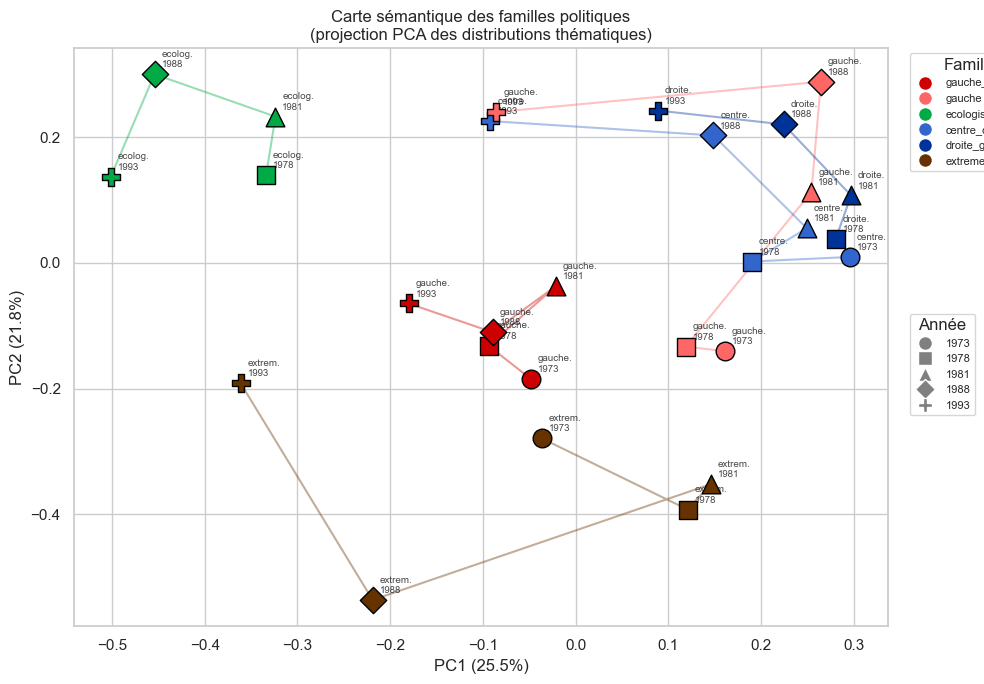


Composition des axes principaux (loadings PCA) :
                                       PC1    PC2
T0: social, entreprise, liberté      0.404 -0.345
T1: national, front, force          -0.116 -0.458
T2: entreprise, travailleur, payer  -0.031 -0.011
T3: france, majorité, député         0.625  0.510
T4: maire, conseiller, général       0.176  0.151
T5: national, immigration, france   -0.307 -0.110
T6: travailleur, contre, droit      -0.094 -0.006
T7: communiste, gauche, parti       -0.078 -0.148
T8: écologie, emploi, environnement -0.539  0.571
T9: travailleur, lutte, voter       -0.012 -0.158
T10: alsace, région, strasbourg     -0.006  0.036
T11: travailleur, voter, gauche     -0.022 -0.032


In [32]:
# Matrice profil indexée par (année, famille)
X = profil.values
labels = profil.index.tolist()

pca = PCA(n_components=2)
coords = pca.fit_transform(X)

# Projection avec couleur par famille et marker par année
FAMILLES_COLORS = {
    'gauche_radicale':  '#cc0000',
    'gauche':           '#ff6666',
    'ecologistes':      '#00aa44',
    'centre_droite':    '#3366cc',
    'droite_gaulliste': '#003399',
    'extreme_droite':   '#663300',
}
MARKERS = {1973: 'o', 1978: 's', 1981: '^', 1988: 'D', 1993: 'P'}

fig, ax = plt.subplots(figsize=(10, 7))

for i, (y, fam) in enumerate(labels):
    ax.scatter(coords[i, 0], coords[i, 1], s=180,
               color=FAMILLES_COLORS.get(fam, 'gray'),
               marker=MARKERS.get(y, 'o'),
               edgecolors='black', linewidths=1, zorder=3)
    ax.annotate(f'{fam[:6]}.\n{y}', (coords[i, 0], coords[i, 1]),
                xytext=(5, 5), textcoords='offset points',
                fontsize=7, alpha=0.85)

# Trajectoires : lier les points d'une même famille dans l'ordre temporel
for fam in FAMILLES:
    points = [(y, i) for i, (y2, f) in enumerate(labels) if f == fam for y in [y2]]
    points.sort()
    if len(points) >= 2:
        xs = [coords[i, 0] for _, i in points]
        ys = [coords[i, 1] for _, i in points]
        ax.plot(xs, ys, '-', color=FAMILLES_COLORS.get(fam, 'gray'),
                alpha=0.4, lw=1.5, zorder=1)

from matplotlib.lines import Line2D
legend1 = [Line2D([0], [0], marker='o', color='w',
                  markerfacecolor=c, markersize=10, label=fam)
           for fam, c in FAMILLES_COLORS.items()]
legend2 = [Line2D([0], [0], marker=m, color='w',
                  markerfacecolor='gray', markersize=10, label=str(y))
           for y, m in MARKERS.items()]
leg1 = ax.legend(handles=legend1, loc='upper left', title='Famille',
                 bbox_to_anchor=(1.02, 1.0), fontsize=8)
ax.add_artist(leg1)
ax.legend(handles=legend2, loc='upper left', title='Année',
          bbox_to_anchor=(1.02, 0.55), fontsize=8)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('Carte sémantique des familles politiques\n(projection PCA des distributions thématiques)')
plt.tight_layout()
plt.savefig('../results/figures/06_carte_familles.png', dpi=150, bbox_inches='tight')
plt.show()

# Composition des axes principaux
print('\nComposition des axes principaux (loadings PCA) :')
loadings = pd.DataFrame(pca.components_.T,
                          index=topic_cols, columns=['PC1', 'PC2'])
print(loadings.round(3))

## 9. Trajectoires diachroniques par famille

Pour chaque famille politique, on trace l'évolution de sa prévalence sur les 3 topics
où elle est la plus distinctive.

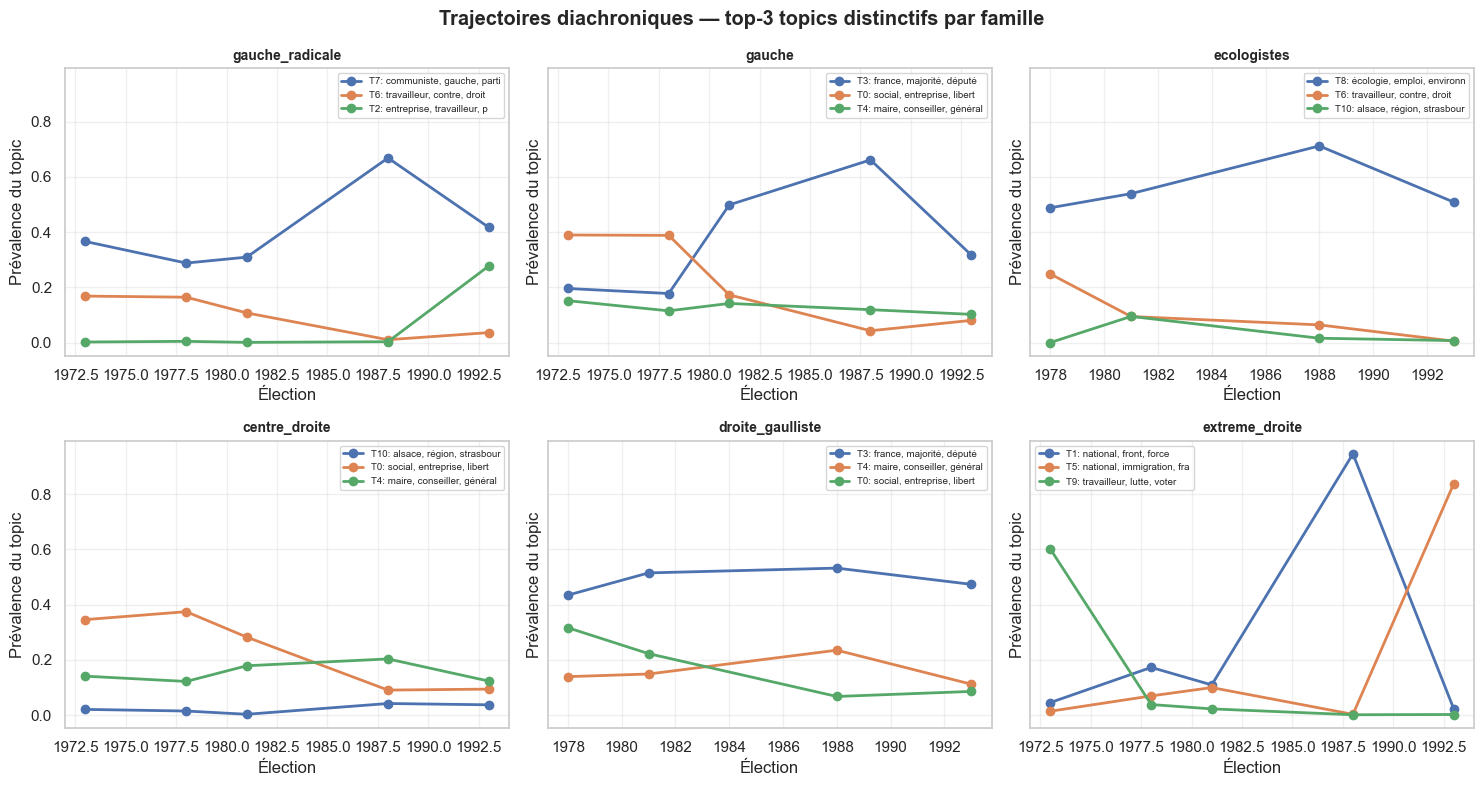

In [33]:
# Pour chaque famille, identifier les 3 topics où le lift est le plus élevé en moyenne
fam_topic_lift = lift.groupby('famille').mean()

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=True)
axes = axes.flatten()

for ax, fam in zip(axes, FAMILLES):
    if fam not in fam_topic_lift.index:
        ax.set_title(f'{fam} (absent)')
        continue
    top3 = fam_topic_lift.loc[fam].nlargest(3).index.tolist()
    for topic in top3:
        years_present, values = [], []
        for y in YEARS:
            if (y, fam) in profil.index:
                years_present.append(y)
                values.append(profil.loc[(y, fam), topic])
        ax.plot(years_present, values, marker='o', label=topic[:30], lw=2)
    ax.set_title(fam, fontsize=10, fontweight='bold')
    ax.set_xlabel('Élection')
    ax.set_ylabel('Prévalence du topic')
    ax.legend(fontsize=7, loc='best')
    ax.grid(alpha=0.3)

plt.suptitle('Trajectoires diachroniques — top-3 topics distinctifs par famille',
             fontweight='bold')
plt.tight_layout()
plt.savefig('../results/figures/06_trajectoires_familles.png', dpi=150)
plt.show()

## 10. Sentiment lexical sur immigration et chômage par famille

Pour les deux mots cibles du notebook 05, on regarde quels topics ils peuplent
et la propension de chaque famille politique à parler de ces topics.

In [34]:
MOTS_FOCUS = ['immigration', 'chômage']

for mot in MOTS_FOCUS:
    if mot not in dictionary.token2id:
        print(f'  {mot} absent du dictionnaire')
        continue

    # Top topics qui contiennent ce mot
    word_id = dictionary.token2id[mot]
    topic_word_weights = []
    for t in range(K):
        weights = dict(lda.show_topic(t, topn=200))
        topic_word_weights.append(weights.get(mot, 0))

    top_topics = np.argsort(topic_word_weights)[::-1][:3]
    print(f'\n=== {mot.upper()} : top 3 topics qui le contiennent ===')
    for t in top_topics:
        print(f'  {TOPIC_LABELS[t]}  (poids du mot dans ce topic : {topic_word_weights[t]:.4f})')

    # Pour chaque famille, sa propension à parler de ces topics
    target_topics = [TOPIC_LABELS[t] for t in top_topics]
    fam_propension = profil.groupby('famille')[target_topics].mean()
    print(f'\nPrévalence moyenne de ces topics par famille (toutes périodes) :')
    print(fam_propension.round(3).sort_values(target_topics[0], ascending=False))


=== IMMIGRATION : top 3 topics qui le contiennent ===
  T5: national, immigration, france  (poids du mot dans ce topic : 0.0143)
  T1: national, front, force  (poids du mot dans ce topic : 0.0066)
  T9: travailleur, lutte, voter  (poids du mot dans ce topic : 0.0026)

Prévalence moyenne de ces topics par famille (toutes périodes) :
                  T5: national, immigration, france  \
famille                                               
extreme_droite                                0.205   
ecologistes                                   0.105   
droite_gaulliste                              0.015   
centre_droite                                 0.009   
gauche                                        0.003   
gauche_radicale                               0.003   

                  T1: national, front, force  T9: travailleur, lutte, voter  
famille                                                                      
extreme_droite                         0.259                        

## 11. Synthèse — tableau drift × topic × famille

Croise les résultats du notebook 04 (drift sémantique) avec ceux du notebook 06
(distribution thématique). Pour chaque mot cible :
- son drift cosinus moyen
- son topic dominant en 1973 (LDA global)
- son topic dominant en 1993
- la famille politique la plus associée à son topic 1993

In [35]:
try:
    drift_df = pd.read_csv('../results/tables/04_drift_scores.csv', index_col='mot')
    has_drift = True
except FileNotFoundError:
    print('⚠ Lancer notebook 04 d\'abord.')
    has_drift = False

if has_drift:
    MOTS_CIBLES = ['immigration', 'chômage', 'sécurité', 'liberté', 'europe',
                   'nation', 'travail', 'social']
    rows = []
    for mot in MOTS_CIBLES:
        if mot not in dictionary.token2id or mot not in drift_df.index:
            continue

        # Topic dominant pour ce mot (LDA global)
        topic_weights = []
        for t in range(K):
            w = dict(lda.show_topic(t, topn=300)).get(mot, 0)
            topic_weights.append((t, w))
        topic_weights.sort(key=lambda x: -x[1])
        best_topic = topic_weights[0][0]

        # Famille la plus associée à ce topic (lift moyen le plus élevé)
        fam_lift = lift.groupby('famille').mean()[TOPIC_LABELS[best_topic]]
        best_fam = fam_lift.idxmax()

        rows.append({
            'mot': mot,
            'drift_moyen': drift_df.loc[mot, 'drift_moyen'],
            'topic_dominant': TOPIC_LABELS[best_topic],
            'famille_associee': best_fam,
            'lift_max': round(fam_lift.max(), 2),
        })

    synth = pd.DataFrame(rows).set_index('mot')
    synth = synth.sort_values('drift_moyen', ascending=False)
    synth.to_csv('../results/tables/06_synthese_drift_topic_famille.csv')
    print('Tableau de synthèse drift × topic × famille :')
    print(synth.to_string())

Tableau de synthèse drift × topic × famille :
             drift_moyen                       topic_dominant  famille_associee  lift_max
mot                                                                                      
immigration       0.5992    T5: national, immigration, france    extreme_droite     10.13
sécurité          0.4450    T5: national, immigration, france    extreme_droite     10.13
chômage           0.4394   T2: entreprise, travailleur, payer   gauche_radicale      1.80
nation            0.4356      T0: social, entreprise, liberté     centre_droite      1.90
travail           0.3812   T2: entreprise, travailleur, payer   gauche_radicale      1.80
europe            0.3674  T8: écologie, emploi, environnement       ecologistes      7.45
social            0.3596      T0: social, entreprise, liberté     centre_droite      1.90
liberté           0.3142         T3: france, majorité, député  droite_gaulliste      2.12
